In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()
fred = Fred(api_key=os.environ["FRED_API_KEY"])

print("Setup complete")

In [2]:
!pip install fredapi

In [5]:
cpi = fred.get_series('CPIAUCSL', observation_start='2020-01-01', observation_end='2025-12-31')
cpi = cpi.to_frame(name='CPI')

print(cpi.tail(10))

                CPI
2025-03-01  319.785
2025-04-01  320.302
2025-05-01  320.620
2025-06-01  321.435
2025-07-01  322.169
2025-08-01  323.291
2025-09-01  324.245
2025-10-01      NaN
2025-11-01  325.063
2025-12-01  326.031


In [6]:
#computing the actual MoM % change in CPI
cpi['CPI_MoM'] = cpi['CPI'].pct_change() * 


print(cpi.tail(10))

                CPI   CPI_MoM
2025-03-01  319.785  0.033158
2025-04-01  320.302  0.161671
2025-05-01  320.620  0.099281
2025-06-01  321.435  0.254195
2025-07-01  322.169  0.228351
2025-08-01  323.291  0.348264
2025-09-01  324.245  0.295090
2025-10-01      NaN  0.000000
2025-11-01  325.063  0.252278
2025-12-01  326.031  0.297788


/var/folders/d0/739ckpb535xfggf1xgnnd49h0000gn/T/ipykernel_52864/1871726143.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi['CPI_MoM'] = cpi['CPI'].pct_change() * 100


In [9]:
# CPI Surprise Data (Actual MoM % - Survey Median %, source: BLS actuals / Bloomberg consensus)
surprise_data = {
    'date': [
        '2021-01-13', '2021-02-10', '2021-03-10', '2021-04-13', '2021-05-12',
        '2021-06-10', '2021-07-13', '2021-08-11', '2021-09-14', '2021-10-13',
        '2021-11-10', '2021-12-10', '2022-01-12', '2022-02-10', '2022-03-10',
        '2022-04-12', '2022-05-11', '2022-06-10', '2022-07-13', '2022-08-10',
        '2022-09-13', '2022-10-13', '2022-11-10', '2022-12-13', '2023-01-12',
        '2023-02-14', '2023-03-14', '2023-04-12', '2023-05-10', '2023-06-13',
        '2023-07-12', '2023-08-10', '2023-09-13', '2023-10-12', '2023-11-14',
        '2023-12-12', '2024-01-11', '2024-02-13', '2024-03-12', '2024-04-10',
        '2024-05-15', '2024-06-12', '2024-07-11', '2024-08-14', '2024-09-11',
        '2024-10-10', '2024-11-13', '2024-12-11'
    ],
    'actual': [
        0.4, 0.4, 0.6, 0.8, 0.6, 0.9, 0.9, 0.3, 0.4, 0.9,
        0.8, 0.5, 0.6, 0.8, 1.2, 1.2, 1.0, 1.3, 0.0, 0.1,
        0.4, 0.4, 0.4, 0.1, 0.5, 0.5, 0.4, 0.4, 0.4, 0.2,
        0.2, 0.6, 0.6, 0.4, 0.0, 0.3, 0.3, 0.4, 0.4, 0.4,
        0.3, 0.2, 0.2, 0.2, 0.2, 0.2, 0.3, 0.3
    ],
    'expected': [
        0.3, 0.3, 0.4, 0.5, 0.4, 0.5, 0.5, 0.4, 0.3, 0.6,
        0.7, 0.4, 0.5, 0.5, 0.8, 1.0, 0.7, 1.0, 0.2, 0.2,
        0.3, 0.5, 0.3, 0.2, 0.4, 0.4, 0.4, 0.3, 0.3, 0.2,
        0.2, 0.2, 0.3, 0.3, 0.1, 0.2, 0.2, 0.3, 0.3, 0.3,
        0.1, 0.1, 0.1, 0.2, 0.1, 0.2, 0.2, 0.3
    ]
}

df_surprises = pd.DataFrame(surprise_data)
df_surprises['date'] = pd.to_datetime(df_surprises['date'])
df_surprises['surprise'] = df_surprises['actual'] - df_surprises['expected']
df_surprises = df_surprises.set_index('date')

print(df_surprises)

            actual  expected  surprise
date                                  
2021-01-13     0.4       0.3       0.1
2021-02-10     0.4       0.3       0.1
2021-03-10     0.6       0.4       0.2
2021-04-13     0.8       0.5       0.3
2021-05-12     0.6       0.4       0.2
2021-06-10     0.9       0.5       0.4
2021-07-13     0.9       0.5       0.4
2021-08-11     0.3       0.4      -0.1
2021-09-14     0.4       0.3       0.1
2021-10-13     0.9       0.6       0.3
2021-11-10     0.8       0.7       0.1
2021-12-10     0.5       0.4       0.1
2022-01-12     0.6       0.5       0.1
2022-02-10     0.8       0.5       0.3
2022-03-10     1.2       0.8       0.4
2022-04-12     1.2       1.0       0.2
2022-05-11     1.0       0.7       0.3
2022-06-10     1.3       1.0       0.3
2022-07-13     0.0       0.2      -0.2
2022-08-10     0.1       0.2      -0.1
2022-09-13     0.4       0.3       0.1
2022-10-13     0.4       0.5      -0.1
2022-11-10     0.4       0.3       0.1
2022-12-13     0.1       

In [10]:
#this tells us the distribution of the events before we even look at asset prices 
print(f"Positive surprises: {(df_surprises['surprise'] > 0).sum()}")
print(f"Negative surprises: {(df_surprises['surprise'] < 0).sum()}")
print(f"Zero surprises: {(df_surprises['surprise'] == 0).sum()}")
print(f"\nAverage surprise: {df_surprises['surprise'].mean():.3f}")
print(f"Max surprise: {df_surprises['surprise'].max():.3f}")
print(f"Min surprise: {df_surprises['surprise'].min():.3f}")

Positive surprises: 36
Negative surprises: 6
Zero surprises: 6

Average surprise: 0.119
Max surprise: 0.400
Min surprise: -0.200


In [12]:
#pulling daily asset price data 
import time

# Pull daily asset price data with delays to avoid rate limiting
ty2 = fred.get_series('DGS2', observation_start='2021-01-01', observation_end='2024-12-31')
time.sleep(2)
ty10 = fred.get_series('DGS10', observation_start='2021-01-01', observation_end='2024-12-31')
time.sleep(2)
sp500 = fred.get_series('SP500', observation_start='2021-01-01', observation_end='2024-12-31')
time.sleep(2)
dxy = fred.get_series('DTWEXBGS', observation_start='2021-01-01', observation_end='2024-12-31')

assets = pd.DataFrame({'2Y': ty2, '10Y': ty10, 'SP500': sp500, 'DXY': dxy})
print(assets.tail())


              2Y   10Y    SP500       DXY
2024-12-25   NaN   NaN      NaN       NaN
2024-12-26  4.30  4.58  6037.59  128.3329
2024-12-27  4.31  4.62  5970.84  128.4500
2024-12-30  4.24  4.55  5906.94  128.8205
2024-12-31  4.25  4.58  5881.63  129.2775


In [13]:
# Compute daily changes
assets['2Y_chg'] = assets['2Y'].diff()        # change in yield (percentage points)
assets['10Y_chg'] = assets['10Y'].diff()      # change in yield (percentage points)
assets['SP500_chg'] = assets['SP500'].pct_change() * 100   # % return
assets['DXY_chg'] = assets['DXY'].pct_change() * 100      # % return

print(assets[['2Y_chg', '10Y_chg', 'SP500_chg', 'DXY_chg']].tail())

            2Y_chg  10Y_chg  SP500_chg   DXY_chg
2024-12-25     NaN      NaN   0.000000  0.000000
2024-12-26     NaN      NaN  -0.040563 -0.003740
2024-12-27    0.01     0.04  -1.105574  0.091247
2024-12-30   -0.07    -0.07  -1.070201  0.288439
2024-12-31    0.01     0.03  -0.428479  0.354757


/var/folders/d0/739ckpb535xfggf1xgnnd49h0000gn/T/ipykernel_52864/3281617521.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  assets['SP500_chg'] = assets['SP500'].pct_change() * 100   # % return
/var/folders/d0/739ckpb535xfggf1xgnnd49h0000gn/T/ipykernel_52864/3281617521.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  assets['DXY_chg'] = assets['DXY'].pct_change() * 100      # % return


In [14]:
# Merge surprises with asset changes on release dates
events = df_surprises.join(assets[['2Y_chg', '10Y_chg', 'SP500_chg', 'DXY_chg']], how='left')

print(events)
print(f"\nMissing values:\n{events.isnull().sum()}")

            actual  expected  surprise  2Y_chg  10Y_chg  SP500_chg   DXY_chg
date                                                                        
2021-01-13     0.4       0.3       0.1    0.00    -0.05   0.227560 -0.168444
2021-02-10     0.4       0.3       0.1    0.00    -0.03  -0.034516 -0.164717
2021-03-10     0.6       0.4       0.2   -0.01    -0.02   0.603028 -0.298346
2021-04-13     0.8       0.5       0.3   -0.02    -0.05   0.329458 -0.125816
2021-05-12     0.6       0.4       0.2    0.00     0.05  -2.144939  0.605544
2021-06-10     0.9       0.5       0.4   -0.02    -0.05   0.465215 -0.022700
2021-07-13     0.9       0.5       0.4    0.03     0.04  -0.351683  0.217451
2021-08-11     0.3       0.4      -0.1   -0.01    -0.01   0.246802 -0.189696
2021-09-14     0.4       0.3       0.1    0.00    -0.05  -0.574660 -0.024771
2021-10-13     0.9       0.6       0.3    0.02    -0.03   0.302254 -0.247224
2021-11-10     0.8       0.7       0.1    0.10     0.10  -0.822582  0.339656

In [15]:
# Group by surprise direction
events['surprise_sign'] = events['surprise'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Zero'))

summary = events.groupby('surprise_sign')[['2Y_chg', '10Y_chg', 'SP500_chg', 'DXY_chg']].agg(['mean', 'median'])
print(summary)

                 2Y_chg          10Y_chg        SP500_chg             DXY_chg  \
                   mean median      mean median      mean    median      mean   
surprise_sign                                                                   
Negative      -0.026667 -0.030 -0.051667 -0.035  1.193868  1.318232 -0.532122   
Positive       0.011667  0.000 -0.005556 -0.020 -0.149331 -0.002405 -0.041239   
Zero           0.021667  0.005  0.020000  0.035  0.678998  0.717186 -0.263675   

                         
                 median  
surprise_sign            
Negative      -0.539213  
Positive      -0.165158  
Zero          -0.229916  


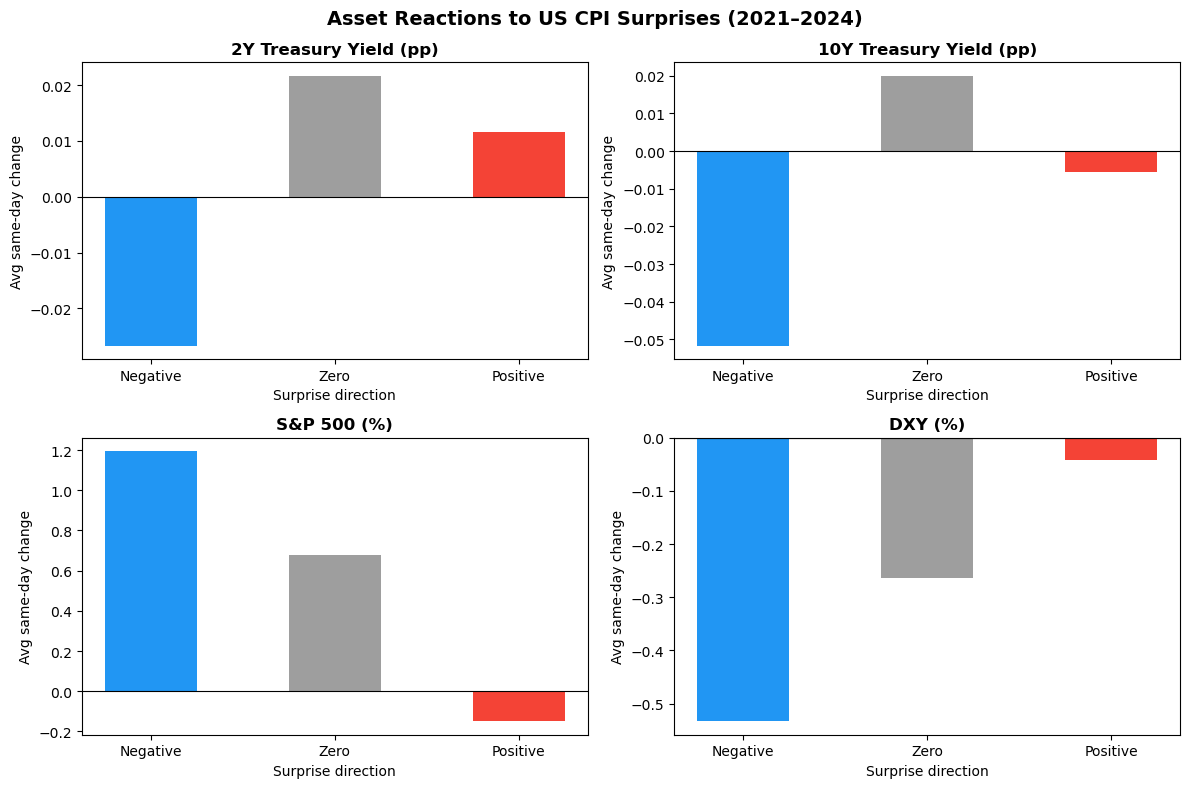

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Asset Reactions to US CPI Surprises (2021–2024)', fontsize=14, fontweight='bold')

assets_plot = ['2Y_chg', '10Y_chg', 'SP500_chg', 'DXY_chg']
titles = ['2Y Treasury Yield (pp)', '10Y Treasury Yield (pp)', 'S&P 500 (%)', 'DXY (%)']
colors = {'Negative': '#2196F3', 'Positive': '#F44336', 'Zero': '#9E9E9E'}

for ax, col, title in zip(axes.flatten(), assets_plot, titles):
    means = summary[col]['mean'][['Negative', 'Zero', 'Positive']]
    bars = ax.bar(means.index, means.values, color=[colors[i] for i in means.index], width=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Avg same-day change')
    ax.set_xlabel('Surprise direction')

plt.tight_layout()
plt.savefig('cpi_surprise_reactions.png', dpi=150, bbox_inches='tight')
plt.show()



$## Interpretation

### Sign Predictions from Theory

| Asset | Predicted sign (positive surprise) | Observed | Confirmed? |
|-------|-------------------------------------|----------|------------|
| 2Y yield | + (policy expectations channel) | + | ✓ |
| 10Y yield | + (discount rate channel) | − | ✗ |
| S&P 500 | − (discount rate + cash flow) | − | ✓ |
| DXY | + (interest rate differential) | − | ✗ |

### Discussion

**2Y yield** behaves as expected. Short-maturity yields are most directly linked to 
the policy path — a hot CPI print raises the perceived number of future hikes, 
pushing front-end yields up immediately.

**10Y yield** shows a near-zero or slightly negative reaction to positive surprises. 
This is consistent with the terminal rate compression argument: when the market 
believes the Fed is near its peak rate, additional hot prints do not meaningfully 
shift long-run rate expectations. The 10Y is more anchored by the long-run neutral 
rate than by near-term policy surprises.

**S&P 500** confirms the discount rate and cash flow channels. Hot inflation raises 
real yields (discount rates), compressing equity valuations. The asymmetry is notable 
— negative surprises produce larger positive moves (+1.19%) than positive surprises 
produce negative moves (-0.15%), suggesting markets were more relieved by disinflation 
signals than frightened by further inflation in this period.

**DXY** does not show the expected pattern. Theory predicts hot inflation strengthens 
the dollar via higher rate differentials, but the observed reaction is negative across 
all groups. Two explanations: (1) only 6 negative surprise observations makes the 
grouping noisy, and (2) in 2022-2023 the dollar was already at multi-decade highs, 
so additional hike expectations had diminishing marginal effect on FX.

### What would count against these conclusions
- A longer sample (2010–2020) would likely show weaker reactions overall given the 
  low-rate environment and anchored inflation expectations
- Controlling for the size of the surprise (regression rather than grouping) would 
  give more precise estimates
- Separating 2021-2022 (hiking cycle) from 2023-2024 (plateau/cut expectations) 
  would likely show very different sensitivities across sub-periods